In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:10pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1절. 군집모델(클러스터링)
- 클러스터(cluster) : 독립변수의 특성이 유사한 데이터의 그룹
- 클러스터링(clustering) : 주어진 데이터를 여러 개의 클러스터로 구분하는 것
1) 중심 기반 클러스터링(K-Means)
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반 클러스터링(DBSCAN) 
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반 클러스터링(DBSCAN의 변형으로 OPTICS) 
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

# 2절. K-Means 클러스터링

In [17]:
import matplotlib.pyplot as plt
# plt.rc('font', family='Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글깨짐 방지
plt.rcParams['axes.unicode_minus'] = False    # 축의 - 깨짐 방지
plt.rcParams['figure.figsize'] = (15,4) # 모든 시각화 사이즈

In [18]:
# 분류를 위한 가상 데이터 셋 생성
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=20, # 데이터 갯수(기본값100) : 20행
                           n_features=2, # 독립변수 갯수(기본값20)
                           n_informative=2, # 독립변수 중 종속변수에 영향을 주는 독립변수 갯수
                           n_redundant=0, # 종속변수에 영향을 안 미치는 독립변수 갯수(기본값2)
                           n_classes=2, #종속 변수의 클래스 수 (0,1)
                           n_clusters_per_class=1, # 각 클래스 당 군의 갯수 (서브그룹이 없음) 
                           random_state=123 
                          )

X.shape, y.shape

((20, 2), (20,))

In [20]:
np.column_stack([X, y])[:3] # np.c_[X, y]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(

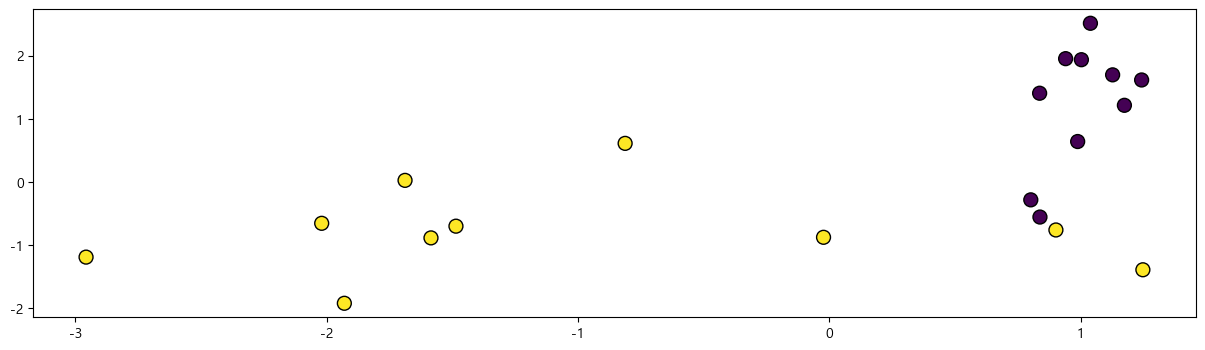

In [21]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='k')
plt.show()

In [22]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 갯수
              init='k-means++', # 초기중심점이 서로 멀리 떨어지도록 똑똑하게 초기화/'random'
              max_iter=300, # 각 실행에서 최대 300번 중심점 이동(중심점이 이동되지 않으면 300까지 안 해)
              n_init='auto'
              )
model.fit(X)

KMeans(n_clusters=2, n_init='auto')

In [23]:
c0, c1 = model.cluster_centers_ # 모델이 선정한 두 클러스터의 중심점
c0, c1

(array([1.01138251, 0.83200493]), array([-1.56258716, -0.69768199]))

In [24]:
print('실제값 :', y)
pred = model.predict(X)
print('예측값 :', pred)
labels = model.labels_
print('라 벨  :', labels)

실제값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
예측값 : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
라 벨  : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]


In [25]:
# 0그룹으로 라벨링
X[labels==0]

array([[ 1.03859554,  2.51175389],
       [ 1.00271366,  1.93521549],
       [ 0.90134424, -0.75896558],
       [ 0.83653082,  1.40488232],
       [ 0.83780453, -0.554389  ],
       [ 1.12694685,  1.69570061],
       [ 0.80138648, -0.28232585],
       [ 0.9399586 ,  1.9518949 ],
       [ 1.24232232,  1.6146173 ],
       [ 1.24732102, -1.38872822],
       [ 0.98786201,  0.64060416],
       [ 1.17380403,  1.21379918]])

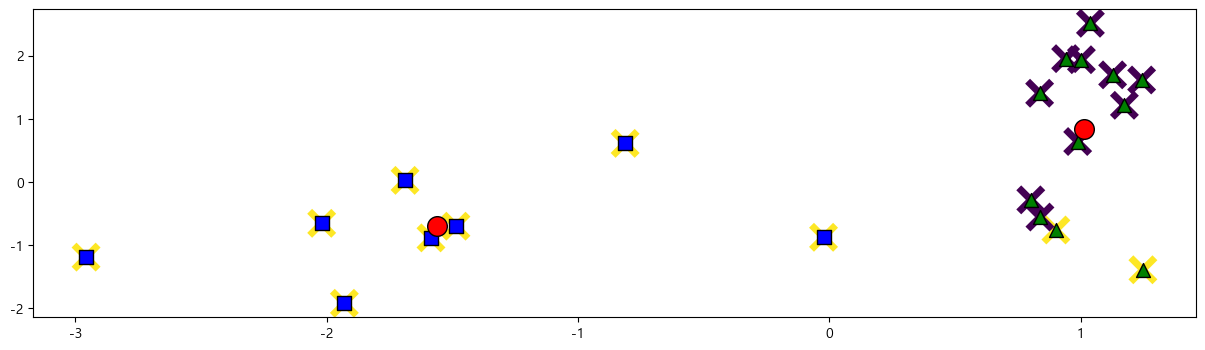

In [26]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=300, marker='x', linewidths=5)
plt.scatter(X[labels==0, 0], X[labels==0, 1], marker='^', c='g', edgecolors='k', s=100)
plt.scatter(X[labels==1, 0], X[labels==1, 1], marker='s', c='b', edgecolors='k', s=100)
plt.scatter(c0[0], c0[1], c='r', s=200, edgecolors='k')
plt.scatter(c1[0], c1[1], c='r', s=200, edgecolors='k')

In [27]:
# X데이터를 Normalizer를 이용한 변환
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
pd.concat([pd.DataFrame(X, columns=['x0', 'x1']),
          pd.DataFrame(Xnor, columns=['x0_nor', 'x1_nor'])],
          axis=1)

,x0,x1,x0_nor,x1_nor
0,1.038596,2.511754,0.382116,0.924114
1,1.002714,1.935215,0.460053,0.887892
2,-1.688105,0.025994,-0.999881,0.015397
3,0.901344,-0.758966,0.764937,-0.644105
4,0.836531,1.404882,0.511615,0.859215
5,-0.023176,-0.874812,-0.026484,-0.999649
6,0.837805,-0.554389,0.833951,-0.551839
7,-1.929572,-1.918940,-0.709057,-0.705151
8,-0.812496,0.611408,-0.799038,0.601281
9,1.126947,1.695701,0.553503,0.832847


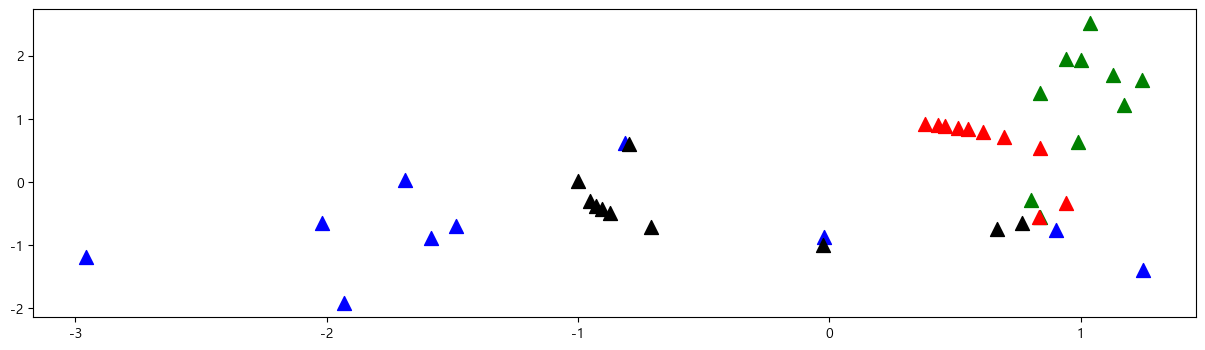

In [31]:
plt.scatter(X[y==0, 0], X[y==0, 1], s=100, marker='^', c='g')
plt.scatter(X[y==1, 0], X[y==1, 1], s=100, marker='^', c='b')

plt.scatter(Xnor[y==0, 0], Xnor[y==0, 1], s=100, marker='^', c='r')
plt.scatter(Xnor[y==1, 0], Xnor[y==1, 1], s=100, marker='^', c='k')

### K-means 클러스터링의 한계 (pdf13p)
- 군의 특성이 다를 경우
    * 크기(Sizes)
    * 밀도(Densities)
    * 비 구형(Non-globular shapes)
- 이상치를 포함할 경우 이상치를 없애고 클러스터링 진행

## 군의 크기가 다를 경우

In [32]:
# np.random.normal(평균, 표준편차, size)
# group0 : 평균 -10, 표준편차 2인 10행 2열 데이터
group0 = np.random.normal(-10, 2, (10, 2))
y0 = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y0]
group0[:3]

array([[-10.86605536, -13.45214187,   0.        ],
       [-13.02564821,  -8.72613962,   0.        ],
       [-10.72312631, -11.39043262,   0.        ]])

In [33]:
# group1 : 평균 10, 표준편차 2인 10행 2열 데이터
group1 = np.random.normal(10, 2, (10, 2))
y1 = np.full(group0.shape[0], 1)
group1 = np.c_[group1, y1]
group1[:3]

array([[ 9.72114082, 10.85344404,  1.        ],
       [ 9.77267751,  9.25528917,  1.        ],
       [ 9.60372302, 10.73669844,  1.        ]])

In [34]:
# group2 : 평균0, 표준편차 5인 100행 2열 데이터
group2 = np.random.normal(0, 5, (100,2))
y2 = np.full(group2.shape[0], 2)
group2 = np.c_[group2, y2]
group2[:3]

array([[ 6.40251604, -0.71612944,  2.        ],
       [ 3.00037011,  6.61146037,  2.        ],
       [-0.35919163, -4.12642467,  2.        ]])

In [35]:
data = np.r_[group0, group1, group2] # 120행3열
data[::10]

array([[-10.86605536, -13.45214187,   0.        ],
       [  9.72114082,  10.85344404,   1.        ],
       [  6.40251604,  -0.71612944,   2.        ],
       [  0.1143299 ,   0.27009038,   2.        ],
       [  2.96466484,  -3.53009412,   2.        ],
       [ -2.32135985,   2.33364918,   2.        ],
       [  2.24110045,  -1.98839137,   2.        ],
       [ 12.62089101,   1.74061959,   2.        ],
       [ -4.27522165,   1.72061898,   2.        ],
       [ -0.82150176,   5.22977488,   2.        ],
       [ 12.88773994,  -6.38223174,   2.        ],
       [ 11.99364853,  -2.1799404 ,   2.        ]])

In [36]:
group0.shape, group1.shape, group2.shape, data.shape

((10, 3), (10, 3), (100, 3), (120, 3))

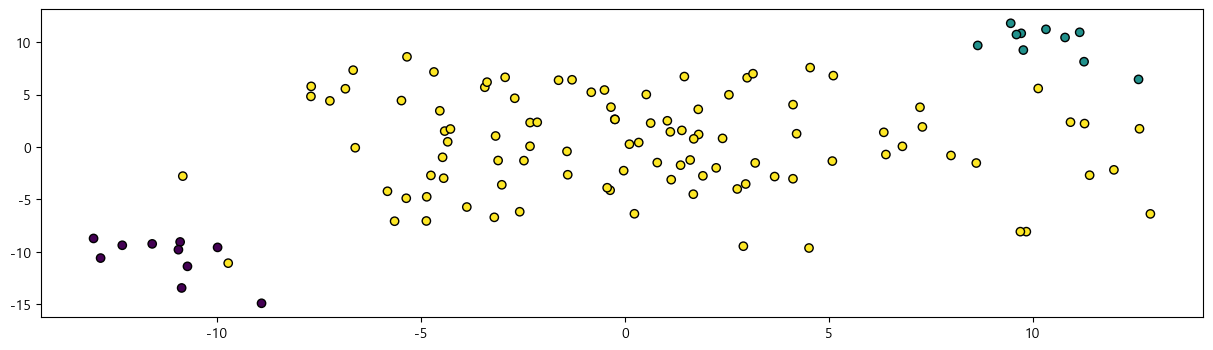

In [37]:
plt.scatter(data[:, 0],  data[:, 1], c=data[:, 2], edgecolors='k')
plt.show()

In [45]:
# 3개그룹으로 클러스터링
model = KMeans(n_clusters=3, n_init=5)
model.fit(data[:, :2])

KMeans(n_clusters=3, n_init=5)

In [46]:
labels = model.labels_ # 모델이 구분한 군들
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 0, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 0, 2, 0, 2, 2, 2, 0, 2,
       2, 1, 2, 0, 0, 1, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 2, 2, 2, 2, 2, 2,
       1, 1, 0, 2, 1, 2, 2, 0, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2,
       0, 2, 2, 2, 0, 0, 1, 2, 2, 2, 0, 2, 1, 2, 2, 0, 2, 2, 2, 2, 1, 2,
       1, 2, 2, 0, 2, 2, 2, 2, 1, 2])

In [47]:
centers = model.cluster_centers_ # 군의 중심점

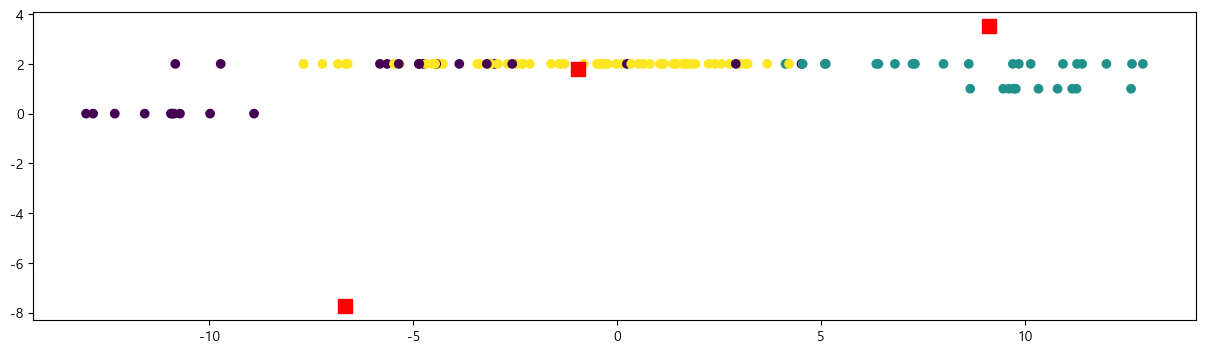

In [48]:
plt.scatter(data[:, 0], data[:, -1], c=labels)
plt.scatter(centers[:,0], centers[:, 1], c='r', s=100, marker='s')

In [42]:
# 6개 그룹으로 클러스터링
model = KMeans(n_clusters=6, n_init=5)
model.fit(data[:, :2])

KMeans(n_clusters=6, n_init=5)

In [49]:
centers = model.cluster_centers_ # 군의 중심점들
centers

array([[-6.66998235, -7.74615019],
       [ 9.12427571,  3.51229553],
       [-0.97222617,  1.79333501]])

In [50]:
labels = model.labels_
labels1 = model.predict(data[:, :2])
np.all(labels==labels1)

True

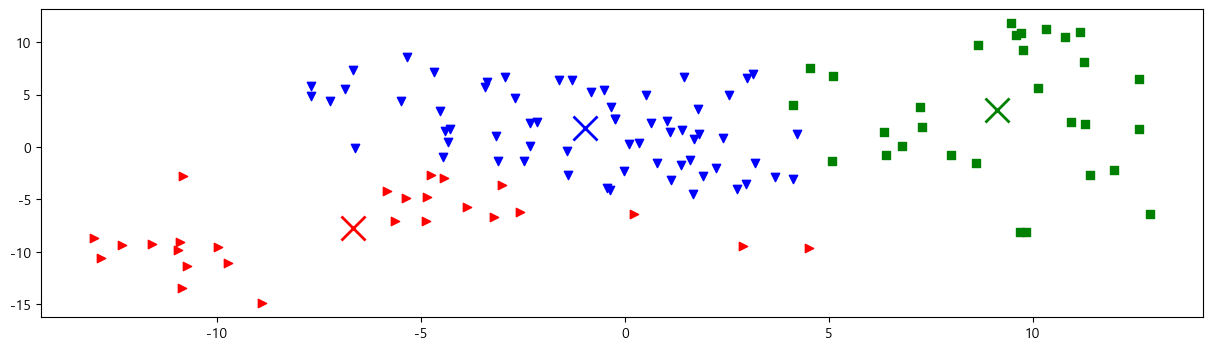

In [51]:
colors = ['r','g','b','c','m','k'] # m:마젠다(보라핑크)
markers = ['>','s','v','^','x','<']
for i, c in enumerate(centers):
    # print(i, c[0], c[1], data[labels==i][:2])
    plt.scatter(x = data[labels==i, 0],
                y = data[labels==i, 1],
                c = colors[i],
                marker=markers[i])
    plt.scatter(c[0], c[1], s=300, c=colors[i], marker='x', linewidths=2)
# 3/ 1,2,4,5 / 0

## 3절. Hierachical 클러스터링(계층적 군집)
- 비슷한 군끼리 묶으면서 하나의 군집이 될 때까지 군을 묶는 알고리즘
- 군집간의 거리를 기반으로 클러스터링을 하는 알고리즘
- 군집의 수를 미리 정해주지 않아도 됨
- dendrogram이라는 그래프를 이용하면 손쉽게 시각화

In [52]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,3.0,1.4,0.2,setosa


In [53]:
# 계층적 군집화를 위해 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species'] = le.fit_transform(iris['species'])
iris.iloc[::50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
50,7.0,3.2,4.7,1.4,1
100,6.3,3.3,6.0,2.5,2


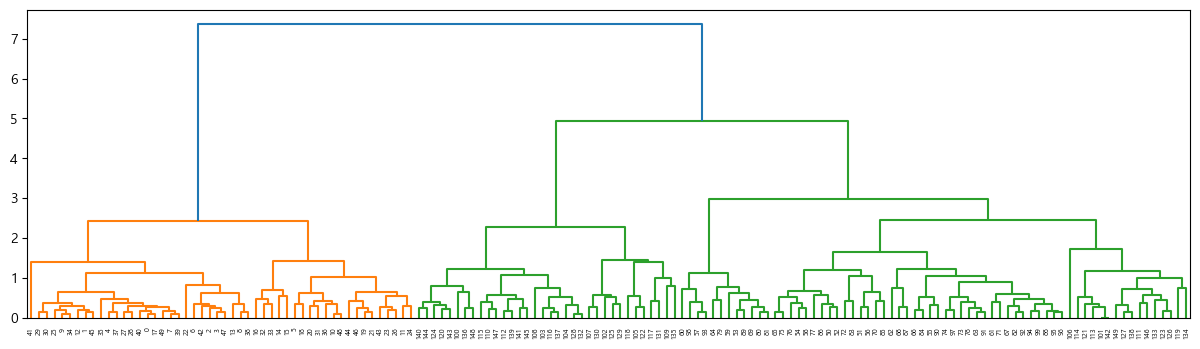

In [58]:
from scipy.cluster.hierarchy import linkage, dendrogram
# method : 각 클러스터 간 거리를 어떻게 계산할지
cluster_model = linkage(iris, method='complete') # 두 클러스터에서 가장 먼 거리를 이용해서 측정
dendrogram(cluster_model, labels=iris.index)
# 파일 저장
plt.savefig('data/ch2_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show() # 화면출력

In [59]:
# 클러스터 생성하는 함수
from scipy.cluster.hierarchy import fcluster
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        6, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [60]:
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        4, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [61]:
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        2, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2,
       1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 2, 1, 6, 6, 6, 5, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 5, 6,
       6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 3, 7, 4, 3, 3, 4, 7, 4, 3, 4,
       3, 7, 3, 7, 7, 3, 3, 4, 4, 7, 3, 7, 4, 7, 3, 4, 7, 7, 3, 4, 4, 4,
       3, 7, 7, 4, 3, 3, 7, 3, 3, 3, 7, 3, 3, 3, 7, 3, 3, 7], dtype=int32)

In [62]:
fcluster(cluster_model, 
        2, # 클러스터의 갯수
        criterion='maxclust')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [63]:
pred = fcluster(cluster_model, 4, criterion='distance')
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [64]:
# 위의 pred를 치환하는 문법
np.choose([1, 1, 3, 3, 2, 2], [0, 0, 2, 1])

array([0, 0, 1, 1, 2, 2])

In [66]:
adjusted_pred = np.choose(pred, [9, 0, 2, 1])
adjusted_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [68]:
pred_name = le.inverse_transform(adjusted_pred)
original_name = le.inverse_transform(iris['species'])
pd.crosstab(original_name, pred_name,
            rownames=['실제값'], colnames=['예측값'],
            margins=True # 행과 열의 총계 추가
           )

예측값,setosa,versicolor,virginica,All
실제값,,,,
setosa,50,0,0,50
versicolor,0,50,0,50
virginica,0,16,34,50
All,50,66,34,150


<Axes: xlabel='petal_length', ylabel='petal_width'>

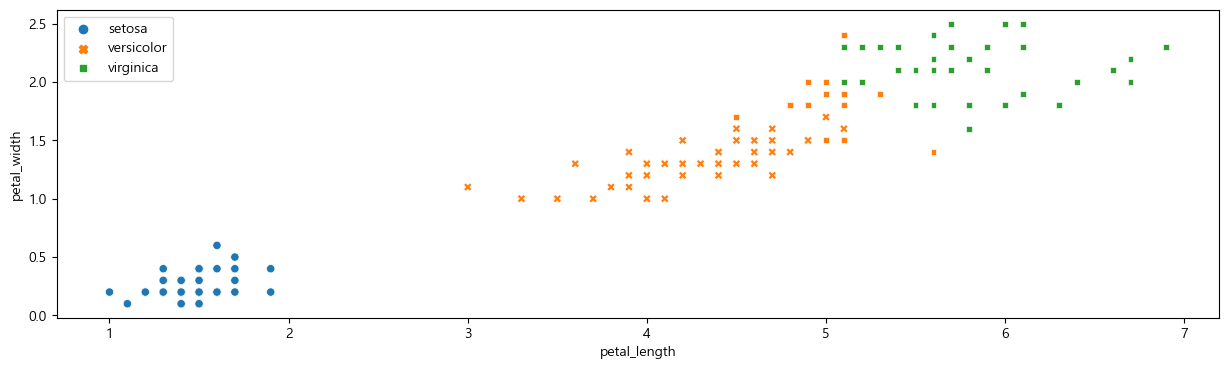

In [71]:
import seaborn as sns
sns.scatterplot(data=iris,
                        x='petal_length',
                        y='petal_width',
                        hue=pred_name,
                        style=original_name)

# 4절 . DBSCAN 클러스터링
- 연결 기반(밀도 기반)군집화 알고리즘(클러스터 수를 미리 정할 필요없음. 이상치를 자동감지)
- 단점 : 클러스터의 밀도가 일정하지 않으면 성능 떨어짐
- eps(반경)과 min_smples(최소 샘플 수)를 적절히 조절하여 군집화

In [75]:
import numpy as np
X1 = np.random.rand(200)*3 # rand(n) : 0<=x<1의 균등포 난수 n개 발생
noise = np.random.normal(0, 0.1, X1.shape)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.zeros(X1.shape[0])]

X2 = X1 + 1.5
noise = np.random.normal(0, 0.2, X1.shape)
Y2 = np.cos(X2)+noise
group2 = np.c_[X2, Y2, np.ones(X2.shape[0])]

data = np.r_[group1, group2]
data[::100]

array([[ 2.98992073,  0.02801574,  0.        ],
       [ 1.90397665,  1.02738458,  0.        ],
       [ 4.48992073, -0.14436255,  1.        ],
       [ 3.40397665, -0.89619374,  1.        ]])

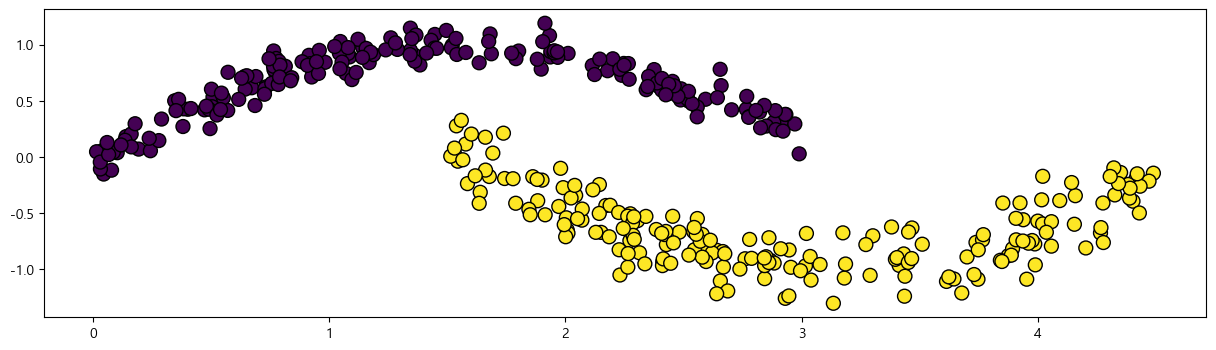

In [80]:
plt.scatter(data[:, 0], data[:, 1], c=data[:,2], s=100, edgecolors='k')

In [81]:
model = KMeans(n_clusters=7, n_init=5)
model.fit(data[:, :2])

KMeans(n_clusters=7, n_init=5)

In [82]:
labels=model.labels_  # 군집화 결과
centers = model.cluster_centers_ # 중심점

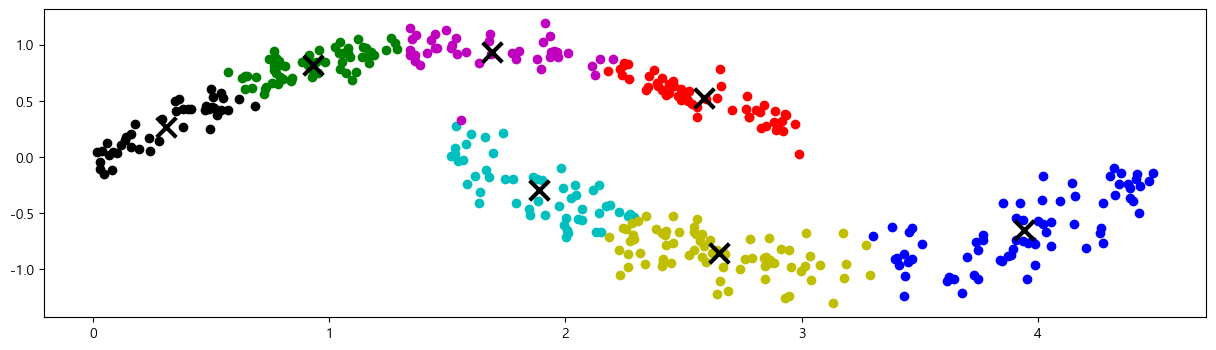

In [83]:
data[labels==1]
colors = ['r','g','b','c','m','k','y'] # 4,2,6,0 / 1,3,5
for i, c in enumerate(centers):
    # print(i, c[0], c[1])
    plt.scatter(data[labels==i, 0], 
               data[labels==i, 1],
               c=colors[i])
    plt.scatter(c[0], c[1], c='k', marker='x', s=200, lw=3)

In [85]:
from sklearn.cluster import DBSCAN
db_model = DBSCAN(eps=0.3, min_samples=10) # 반경0.3이내에 최소 10개가 있어야 군집
db_model.fit(data[:, :2])

DBSCAN(eps=0.3, min_samples=10)

In [92]:
labels = db_model.labels_
#print(labels) # -1은 이상치
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f'이상치를 제외한 label 갯수 :{n_clusters}, 이상치 갯수:{n_noise}')

이상치를 제외한 label 갯수 :2, 이상치 갯수:0


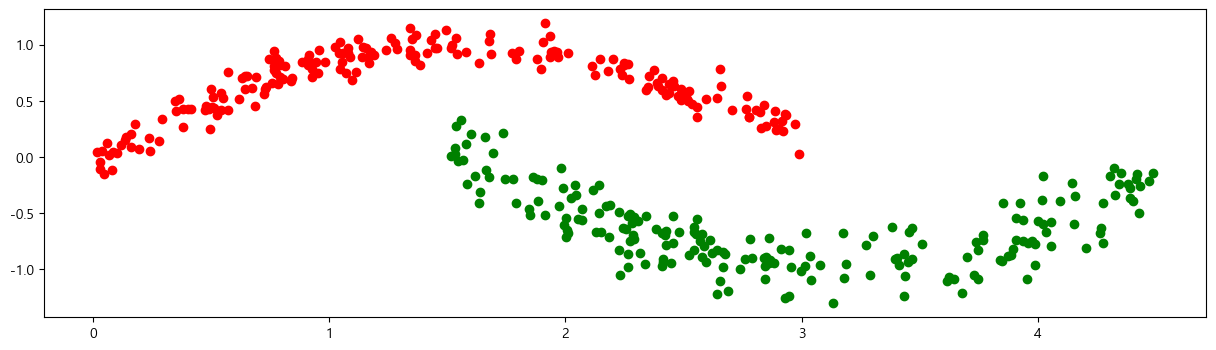

In [91]:
colors = ['r','g']
markers = ['^', 's']
for i in range(n_clusters):
    plt.scatter(data[labels==i, 0],
               data[labels==i, 1],
               c=colors[i])
plt.scatter(data[labels==-1, 0],
           data[labels==-1, 1], 
           c='k',
           marker='x',
           s=100)

# 5절. 군집모형 성능평가
- 예측 모형의 score(분류, 회귀)
    * score메소드를 통해서 예측 모형의 정확도를 평가
- metrics 패키지
    * 분류분석 recall, precision을 평가하는 함수
    * **군집 모형들의 평가를 위한 함수**
- scoring 매개변수
    - GridSearchCV클래스 → 4장

In [94]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris_X = iris.iloc[:, :-1]
iris_y = iris.iloc[:, -1]

In [95]:
from sklearn.cluster import KMeans
iris_3cluster_model = KMeans(n_clusters=3, random_state=1, n_init=10)
iris_3cluster_model.fit(iris_X)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [96]:
# pred3 = iris_3cluster_model.labels_
pred3 = iris_3cluster_model.predict(iris_X)
pred3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [97]:
pred3_str = np.choose(pred3, ['versicolor','setosa','virginica']) # 모델이 군집화한 데이터
# 군집분석의 성능 평가 함수를 쓰기 위해서 pred3_str(넘파이배열)과 iris_y(시리즈)

In [98]:
# iris_y를 라벨인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_y3 = le.fit_transform(iris_y)
pred3 = np.choose(pred3, [1, 0, 2])
# 군집분석의 성능 평가 함수를 쓰기 위해 pred3과 iris_y3(둘다 넘파이 배열)

In [99]:
pd.crosstab(iris_y, pred3_str)

col_0,setosa,versicolor,virginica
species,,,
setosa,50,0,0
versicolor,0,48,2
virginica,0,14,36


In [100]:
from sklearn.cluster import KMeans
iris_2cluster_model = KMeans(n_clusters=2, random_state=1, n_init=10)
iris_2cluster_model.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [101]:
# pred2 = iris_2cluster_model.labels_
pred2 = iris_2cluster_model.predict(iris_X)

In [102]:
iris_y2 = np.array([0]*50 + [1]*100)
# 군집분석의 성능 평가 함수를 쓰기 위해 pred2과 iris_y2(둘다 넘파이 배열)

In [103]:
pred2_str = np.choose(pred2, ['setosa','그외'])
iris_y2_str = np.choose(iris_y2, ['setosa', '그외'])
# 군집분석의 성능 평가 함수를 쓰기 위해 pred2_str과 iris_y2_str(둘다 넘파이 배열)

In [104]:
pd.crosstab(iris_y2_str, pred2_str)

col_0,setosa,그외
row_0,,
setosa,50,0
그외,3,97


In [105]:
pred3_str[:2], iris_y[:2], pred3[:2], iris_y3[:2]

(array(['setosa', 'setosa'], dtype='<U10'),
 0    setosa
 1    setosa
 Name: species, dtype: object,
 array([0, 0]),
 array([0, 0]))

In [106]:
pred2[:2], iris_y2[:2], pred2_str[:2], iris_y2_str[:2]

(array([0, 0]),
 array([0, 0]),
 array(['setosa', 'setosa'], dtype='<U6'),
 array(['setosa', 'setosa'], dtype='<U6'))

In [107]:
pred3_str.shape, iris_y.shape, pred3.shape, iris_y3.shape

((150,), (150,), (150,), (150,))

In [109]:
pred2.shape, iris_y2.shape, pred2_str.shape, iris_y2_str.shape

((150,), (150,), (150,), (150,))

##  5.1 조정된 rand 지수
- 조정된 랜드지수는 pred, iris_y가 얼마나 같은 쌍을 만들어내는지 

In [110]:
# 클러스터갯수가 3개인 경우 성능 평가
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(labels_true=iris_y,
                   labels_pred=pred3_str)

0.7302382722834697

In [111]:
adjusted_rand_score(labels_true=iris_y3,
                   labels_pred=pred3)

0.7302382722834697

In [112]:
# 클러스터갯수가 2개인 경우 성능 평가
adjusted_rand_score(labels_true=iris_y2,
                   labels_pred=pred2)

0.920405050901892

In [113]:
adjusted_rand_score(labels_true=iris_y2_str,
                   labels_pred=pred2_str)

0.920405050901892

## 5.2 상호 의존도를 나타내는 지표
- mutual_info_score : 0 ~ 무한대
- normalized_mutual_info_score : 0~1

In [115]:
from sklearn.metrics import mutual_info_score
# 클러스터가 3인 경우 : 클러스터 갯수가 높으면 잘 나오는 경향이 있음 => 정규화된 mutual_info_score
print(mutual_info_score(iris_y, pred3_str))
print(mutual_info_score(iris_y3, pred3))

0.8255910976103356
0.8255910976103356


In [116]:
# 클러스터가 2인 경우
print(mutual_info_score(iris_y2, pred2))
print(mutual_info_score(iris_y2_str, pred2_str))

0.5596576064224734
0.5596576064224734


In [117]:
from sklearn.metrics import normalized_mutual_info_score
print(normalized_mutual_info_score(iris_y, pred3_str))
print(normalized_mutual_info_score(iris_y3, pred3))

0.7581756800057784
0.7581756800057784


In [118]:
# 클러스터가 2인 경우
print(normalized_mutual_info_score(iris_y2, pred2))
print(normalized_mutual_info_score(iris_y2_str, pred2_str))

0.8703851565631638
0.8703851565631638


## 5.3 그 외 클러스터링 성능 평가 기준 함수들

In [119]:
from sklearn.metrics import homogeneity_score
print(homogeneity_score(iris_y, pred3_str)) # 클러스터가 3
print(homogeneity_score(iris_y3, pred3))

0.7514854021988338
0.7514854021988338


In [120]:
print(homogeneity_score(iris_y2, pred2))
print(homogeneity_score(iris_y2_str, pred2_str))

0.8792539652679946
0.8792539652679946


In [121]:
from sklearn.metrics import completeness_score
print(completeness_score(iris_y, pred3)) # 클러스터 3
print(completeness_score(iris_y2, pred2)) # 클러스터 2

0.7649861514489815
0.861693475999054


## 5.4 실루엣 계수
- 앞의 경우 클러스터의 갯수와 소속을 알ㄹ고 있을 경우 평가하는 방법
- 아래의 경우는 클러스터의 갯수와 소속을 모르고 있을 경우 평가하는 방법

In [122]:
import numpy as np
X1 = np.random.rand(200)*3 # rand(n) : 0<=x<1의 균등포 난수 n개 발생
noise = np.random.normal(0, 0.1, X1.shape)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.zeros(X1.shape[0])]

X2 = X1 + 1.5
noise = np.random.normal(0, 0.2, X1.shape)
Y2 = np.cos(X2)+noise
group2 = np.c_[X2, Y2, np.ones(X2.shape[0])]

data = np.r_[group1, group2]
data[::100]

array([[ 2.02861788,  0.91606551,  0.        ],
       [ 2.82113613,  0.42210419,  0.        ],
       [ 3.52861788, -0.93258258,  1.        ],
       [ 4.32113613, -0.27336374,  1.        ]])